<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png" width="400"></p>

# Домашнее задание. Обучение языковой модели с помощью LSTM (10 баллов)

В этом задании Вам предстоит обучить языковую модель с помощью рекуррентной нейронной сети. В отличие от семинарского занятия, Вам необходимо будет работать с отдельными словами, а не буквами.


Установим модуль ```datasets```, чтобы нам проще было работать с данными.

In [ ]:
!pip install datasets

Импорт необходимых библиотек

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.model_selection import train_test_split
import nltk

from collections import Counter
from typing import List

import seaborn
seaborn.set(palette='summer')

In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Подготовка данных

Воспользуемся датасетом imdb. В нем хранятся отзывы о фильмах с сайта imdb. Загрузим данные с помощью функции ```load_dataset```

In [ ]:
# Загрузим датасет
dataset = load_dataset('imdb')

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

# Препроцессинг данных и создание словаря (1 балл)

Далее вам необходмо самостоятельно произвести препроцессинг данных и получить словарь или же просто ```set``` строк. Что необходимо сделать:

1. Разделить отдельные тренировочные примеры на отдельные предложения с помощью функции ```sent_tokenize``` из бибилиотеки ```nltk```. Каждое отдельное предложение будет одним тренировочным примером.
2. Оставить только те предложения, в которых меньше ```word_threshold``` слов.
3. Посчитать частоту вхождения каждого слова в оставшихся предложениях. Для деления предложения на отдельные слова удобно использовать функцию ```word_tokenize```.
4. Создать объект ```vocab``` класса ```set```, положить в него служебные токены '\<unk\>', '\<bos\>', '\<eos\>', '\<pad\>' и vocab_size самых частовстречающихся слов.   

In [ ]:
sentences = []
word_threshold = 32

for text in dataset['train']['text']:
    text_sentences = sent_tokenize(text)
    for sentence in text_sentences:
        if len(word_tokenize(sentence)) < word_threshold:
            sentences.append(sentence)

In [ ]:
print("Всего предложений:", len(sentences))

Всего предложений: 198801


Посчитаем для каждого слова его встречаемость.

In [ ]:
words = Counter()

for example in tqdm(sentences):
    for tok in word_tokenize(example.lower()):
        words[tok] += 1

  0%|          | 0/198801 [00:00<?, ?it/s]

Добавим в словарь ```vocab_size``` самых встречающихся слов.

In [ ]:
vocab = set()
vocab_size = 40000

vocab.update({'<unk>', '<bos>', '<eos>', '<pad>'})

for word, _ in words.most_common(vocab_size):
    vocab.add(word)

In [ ]:
assert '<unk>' in vocab
assert '<bos>' in vocab
assert '<eos>' in vocab
assert '<pad>' in vocab
assert len(vocab) == vocab_size + 4

In [ ]:
print("Всего слов в словаре:", len(vocab))

Всего слов в словаре: 40004


# Подготовка датасета (1 балл)

Далее, как и в семинарском занятии, подготовим датасеты и даталоадеры.

В классе ```WordDataset``` вам необходимо реализовать метод ```__getitem__```, который будет возвращать сэмпл данных по входному idx, то есть список целых чисел (индексов слов).

Внутри этого метода необходимо добавить служебные токены начала и конца последовательности, а также токенизировать соответствующее предложение с помощью ```word_tokenize``` и сопоставить ему индексы из ```word2ind```.

In [ ]:
word2ind = {char: i for i, char in enumerate(vocab)}
ind2word = {i: char for char, i in word2ind.items()}

In [ ]:
class WordDataset:
    def __init__(self, sentences):
        self.data = sentences
        self.unk_id = word2ind['<unk>']
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.pad_id = word2ind['<pad>']

    def __getitem__(self, idx: int) -> List[int]:
        tokenized_sentence = []
        tokenized_sentence += [self.bos_id]
        tokens = word_tokenize(self.data[idx].lower())
        tokenized_sentence += [word2ind.get(t, self.unk_id) for t in tokens]
        tokenized_sentence += [self.eos_id]

        return tokenized_sentence

    def __len__(self) -> int:
        return len(self.data)

In [ ]:
def collate_fn_with_padding(
    input_batch: List[List[int]], pad_id=word2ind['<pad>']) -> torch.Tensor:
    seq_lens = [len(x) for x in input_batch]
    max_seq_len = max(seq_lens)

    new_batch = []
    for sequence in input_batch:
        for _ in range(max_seq_len - len(sequence)):
            sequence.append(pad_id)
        new_batch.append(sequence)

    sequences = torch.LongTensor(new_batch).to(device)

    new_batch = {
        'input_ids': sequences[:,:-1],
        'target_ids': sequences[:,1:]
    }

    return new_batch

In [ ]:
train_sentences, eval_sentences = train_test_split(sentences, test_size=0.2)
eval_sentences, test_sentences = train_test_split(eval_sentences, test_size=0.5)

train_dataset = WordDataset(train_sentences)
eval_dataset = WordDataset(eval_sentences)
test_dataset = WordDataset(test_sentences)

batch_size = 128

train_dataloader = DataLoader(
    train_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

eval_dataloader = DataLoader(
    eval_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

test_dataloader = DataLoader(
    test_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

## Обучение и архитектура модели

Вам необходимо на практике проверить, что влияет на качество языковых моделей. В этом задании нужно провести серию экспериментов с различными вариантами языковых моделей и сравнить различия в конечной перплексии на тестовом множестве.

Возмоэные идеи для экспериментов:

* Различные RNN-блоки, например, LSTM или GRU. Также можно добавить сразу несколько RNN блоков друг над другом с помощью аргумента num_layers. Вам поможет официальная документация [здесь](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)
* Различные размеры скрытого состояния. Различное количество линейных слоев после RNN-блока. Различные функции активации.
* Добавление нормализаций в виде Dropout, BatchNorm или LayerNorm
* Различные аргументы для оптимизации, например, подбор оптимального learning rate или тип алгоритма оптимизации SGD, Adam, RMSProp и другие
* Любые другие идеи и подходы

После проведения экспериментов необходимо составить таблицу результатов, в которой описан каждый эксперимент и посчитана перплексия на тестовом множестве.

Учтите, что эксперименты, которые различаются, например, только размером скрытого состояния или количеством линейных слоев считаются, как один эксперимент.

Успехов!

# Функция evaluate (1 балл)

Заполните функцию ```evaluate```

In [ ]:
def evaluate(model, criterion, dataloader) -> float:
    model.eval()
    perplexity = []
    with torch.no_grad():
        for batch in dataloader:
            logits = model(batch['input_ids']).flatten(0, -2)
            loss = criterion(logits, batch['target_ids'].flatten())
            perplexity.append(torch.exp(loss).item())

    perplexity = sum(perplexity) / len(perplexity)

    return perplexity

# Train loop (1 балл)

Напишите функцию для обучения модели.

In [ ]:
def train_model(model, train_dataloader, eval_dataloader, criterion, optimizer, num_epoch=5):
    losses, perplexities = [], []
    for epoch in range(num_epoch):
        epoch_losses = []
        model.train()
        for i, batch in enumerate(tqdm(train_dataloader, desc=f'Training epoch {epoch}:')):
            optimizer.zero_grad()
            logits = model(batch['input_ids']).flatten(0, -2)
            loss = criterion(logits, batch['target_ids'].flatten())
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())

        losses.append(sum(epoch_losses) / len(epoch_losses))
        perplexities.append(evaluate(model, criterion, eval_dataloader))
    return losses, perplexities


# Первый эксперимент (2 балла)

Определите архитектуру модели и обучите её.

In [ ]:
class LanguageModel(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(0.1)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embeddings = self.embedding(input_batch)
        output, _ = self.rnn(embeddings)
        output = self.dropout(self.linear(self.non_lin(output)))
        projection = self.projection(self.non_lin(output))

        return projection

### Базовая модель (LSTM, hidden_dim=128, num_layers=1)

In [ ]:
model = LanguageModel(hidden_dim=128, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
losses, perplexities = train_model(model, train_dataloader, eval_dataloader, criterion, optimizer, num_epoch=10)

Training epoch 0::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 5::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 6::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 7::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 8::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 9::   0%|          | 0/1243 [00:00<?, ?it/s]

Перплексия на тестовом множестве:

In [ ]:
test_ppl = evaluate(model, criterion, test_dataloader)
test_ppl

73.66925484302575

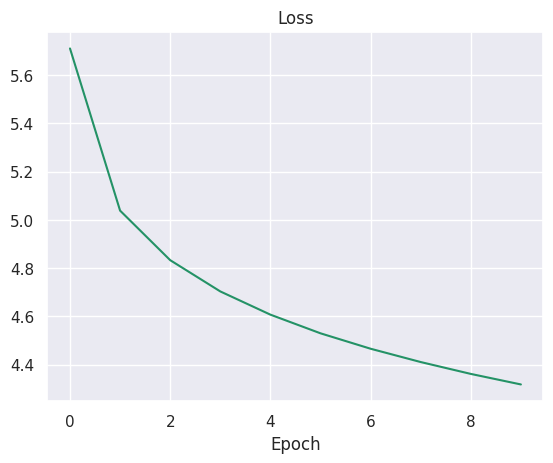

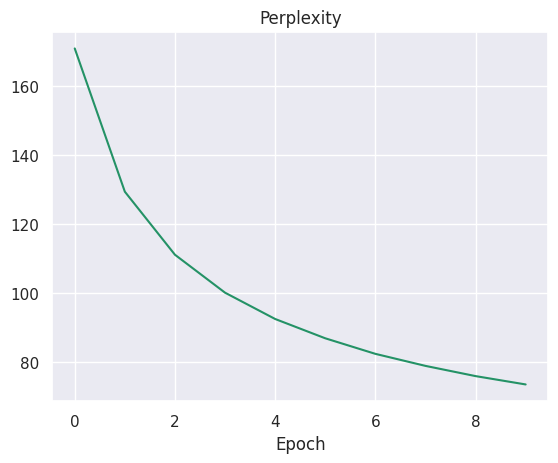

In [ ]:
plt.plot(np.arange(len(losses)), losses)
plt.title('Loss')
plt.xlabel('Epoch')
plt.show()

plt.plot(np.arange(len(perplexities)), perplexities)
plt.title('Perplexity')
plt.xlabel('Epoch')
plt.show()

### Вдвое больший hidden_dim

In [ ]:
model = LanguageModel(hidden_dim=256, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
losses_256, perplexities_256 = train_model(model, train_dataloader, eval_dataloader, criterion, optimizer, num_epoch=10)

Training epoch 0::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 5::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 6::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 7::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 8::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 9::   0%|          | 0/1243 [00:00<?, ?it/s]

Перплексия на тестовом множестве:

In [ ]:
test_ppl_256 = evaluate(model, criterion, test_dataloader)
test_ppl_256

55.0965873296043

### Вдвое меньший hidden_dim

In [ ]:
model = LanguageModel(hidden_dim=64, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
losses_64, perplexities_64 = train_model(model, train_dataloader, eval_dataloader, criterion, optimizer, num_epoch=10)

Training epoch 0::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 5::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 6::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 7::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 8::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 9::   0%|          | 0/1243 [00:00<?, ?it/s]

Перплексия на тестовом множестве:

In [ ]:
test_ppl_64 = evaluate(model, criterion, test_dataloader)
test_ppl_64

102.55159428619817

Посмотрим на графики:

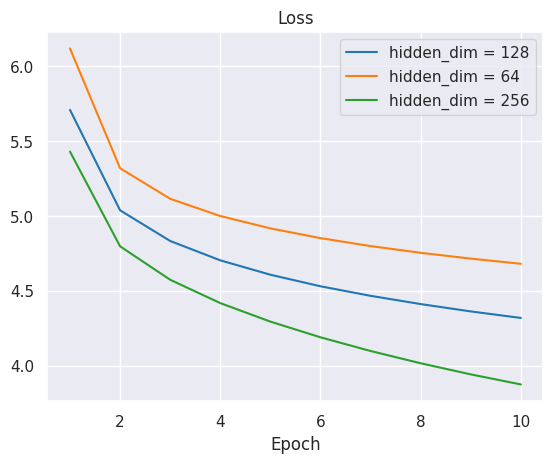

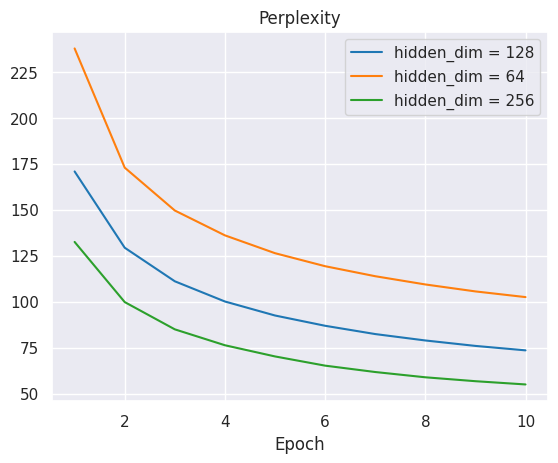

In [ ]:
plt.plot(np.arange(1, len(losses)+1),   losses,   label='hidden_dim = 128', color='tab:blue')
plt.plot(np.arange(1, len(losses_64)+1), losses_64, label='hidden_dim = 64', color='tab:orange')
plt.plot(np.arange(1, len(losses_256)+1), losses_256, label='hidden_dim = 256', color='tab:green')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

plt.plot(np.arange(1, len(perplexities)+1), perplexities,   label='hidden_dim = 128', color='tab:blue')
plt.plot(np.arange(1, len(perplexities_64)+1), perplexities_64, label='hidden_dim = 64', color='tab:orange')
plt.plot(np.arange(1, len(perplexities_256)+1), perplexities_256, label='hidden_dim = 256', color='tab:green')
plt.title('Perplexity')
plt.xlabel('Epoch')
plt.legend()
plt.show()

И по лоссу, и по перплексии можно заметить, что больший размер скрытого состояния будет более удачным выбором для нашей модели.

# Второй эксперимент (2 балла)
Попробуйте что-то поменять в модели или в пайплайне обучения, идеи для экспериментов можно подсмотреть выше. И менять мы будем рекуррентный слой.

 ### GRU

In [ ]:
class GRUModel(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(0.1)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embeddings = self.embedding(input_batch)
        output, _ = self.rnn(embeddings)
        output = self.dropout(self.linear(self.non_lin(output)))
        projection = self.projection(self.non_lin(output))

        return projection

In [ ]:
model = GRUModel(hidden_dim=128, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
losses_gru, perplexities_gru = train_model(model, train_dataloader, eval_dataloader, criterion, optimizer, num_epoch=10)
evaluate(model, criterion, test_dataloader)

Training epoch 0::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/1243 [00:00<?, ?it/s]

...

Training epoch 6::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 7::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 8::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 9::   0%|          | 0/1243 [00:00<?, ?it/s]

77.49275085272475

Перплексия на тестовом множестве:

In [ ]:
test_ppl_gru = evaluate(model, criterion, test_dataloader)
test_ppl_gru

77.49275085272475

### RNN

In [ ]:
class RNNModel(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.RNN(hidden_dim, hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(0.1)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embeddings = self.embedding(input_batch)
        output, _ = self.rnn(embeddings)
        output = self.dropout(self.linear(self.non_lin(output)))
        projection = self.projection(self.non_lin(output))

        return projection

In [ ]:
model = RNNModel(hidden_dim=128, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
losses_rnn, perplexities_rnn = train_model(model, train_dataloader, eval_dataloader, criterion, optimizer, num_epoch=10)

Training epoch 0::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 5::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 6::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 7::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 8::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 9::   0%|          | 0/1243 [00:00<?, ?it/s]

Перплексия на тестовом множестве:

In [ ]:
test_ppl_rnn = evaluate(model, criterion, test_dataloader)
test_ppl_rnn

83.9585760403784

Посмотрим на графики:

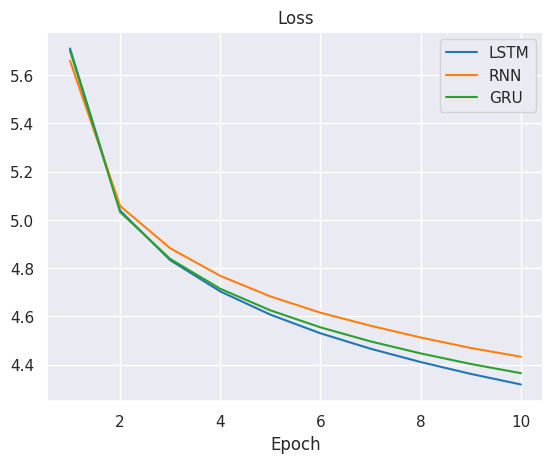

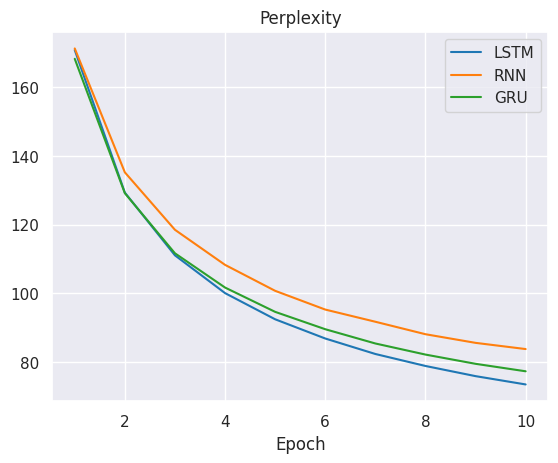

In [ ]:
plt.plot(np.arange(1, len(losses)+1),   losses,   label='LSTM', color='tab:blue')
plt.plot(np.arange(1, len(losses_rnn)+1), losses_rnn, label='RNN', color='tab:orange')
plt.plot(np.arange(1, len(losses_gru)+1), losses_gru, label='GRU', color='tab:green')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

plt.plot(np.arange(1, len(perplexities)+1), perplexities,   label='LSTM', color='tab:blue')
plt.plot(np.arange(1, len(perplexities_rnn)+1), perplexities_rnn, label='RNN', color='tab:orange')
plt.plot(np.arange(1, len(perplexities_gru)+1), perplexities_gru, label='GRU', color='tab:green')
plt.title('Perplexity')
plt.xlabel('Epoch')
plt.legend()
plt.show()

Разница не столь велика, как в прошлом эксперименте, но тем не менее GRU и особенно LSTM превосходят обычный RNN

# Третий эксперимент

### num_layers=2

In [ ]:
class LSTM2Model(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.LSTM(hidden_dim, hidden_dim, num_layers=2, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(0.1)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embeddings = self.embedding(input_batch)
        output, _ = self.rnn(embeddings)
        output = self.dropout(self.linear(self.non_lin(output)))
        projection = self.projection(self.non_lin(output))

        return projection

In [ ]:
model = LSTM2Model(hidden_dim=128, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
losses_2, perplexities_2 = train_model(model, train_dataloader, eval_dataloader, criterion, optimizer, num_epoch=10)

Training epoch 0::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 5::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 6::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 7::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 8::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 9::   0%|          | 0/1243 [00:00<?, ?it/s]

Перплексия на тестовом множестве:

In [ ]:
test_ppl_2 = evaluate(model, criterion, test_dataloader)
test_ppl_2

81.51039453945872

### num_layers=3

In [ ]:
class LSTM3Model(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.LSTM(hidden_dim, hidden_dim, num_layers=3, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(0.1)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embeddings = self.embedding(input_batch)
        output, _ = self.rnn(embeddings)
        output = self.dropout(self.linear(self.non_lin(output)))
        projection = self.projection(self.non_lin(output))

        return projection

In [ ]:
model = LSTM3Model(hidden_dim=128, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
losses_3, perplexities_3 = train_model(model, train_dataloader, eval_dataloader, criterion, optimizer, num_epoch=10)


Training epoch 0::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 5::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 6::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 7::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 8::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 9::   0%|          | 0/1243 [00:00<?, ?it/s]

Перплексия на тестовом множестве:

In [ ]:
test_ppl_3 = evaluate(model, criterion, test_dataloader)
test_ppl_3

91.5054288493467

Посмотрим на графики:

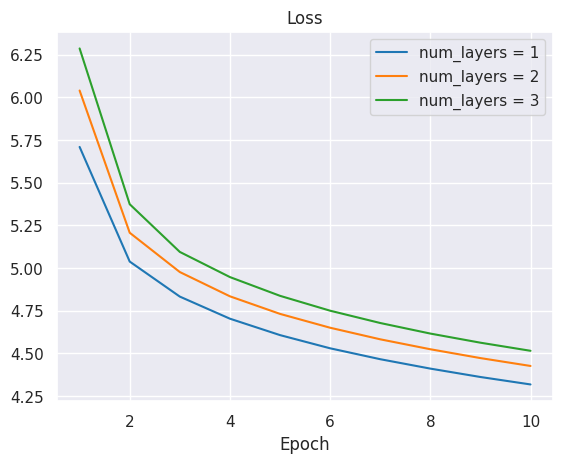

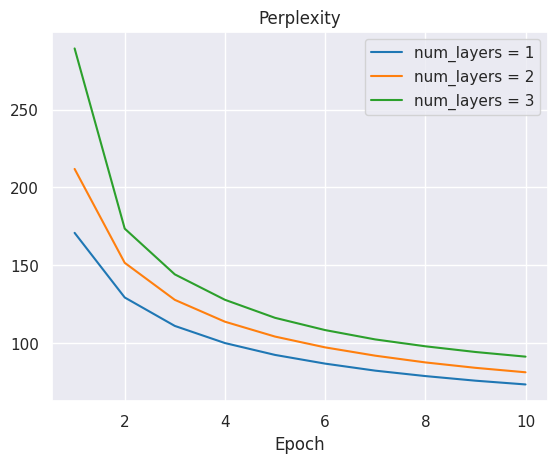

In [ ]:
plt.plot(np.arange(1, len(losses)+1),   losses,   label='num_layers = 1', color='tab:blue')
plt.plot(np.arange(1, len(losses_2)+1), losses_2, label='num_layers = 2', color='tab:orange')
plt.plot(np.arange(1, len(losses_3)+1), losses_3, label='num_layers = 3', color='tab:green')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

plt.plot(np.arange(1, len(perplexities)+1), perplexities,   label='num_layers = 1', color='tab:blue')
plt.plot(np.arange(1, len(perplexities_2)+1), perplexities_2, label='num_layers = 2', color='tab:orange')
plt.plot(np.arange(1, len(perplexities_3)+1), perplexities_3, label='num_layers = 3', color='tab:green')
plt.title('Perplexity')
plt.xlabel('Epoch')
plt.legend()
plt.show()

C количеством слоев принцип "чем больше, тем лучше" не работает. В нашем эксперимене наилучшие результаты показывает модель с одним рекуррентным слоем. Скорей всего, ухудшение метрики при увеличении количество слоев связано с затуханием градиентов.

# Четвертый эксперимент

### Вдвое больший dropout

In [ ]:
class LSTM_Do2_Model(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.LSTM(hidden_dim, hidden_dim, num_layers=1, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(0.2)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embeddings = self.embedding(input_batch)
        output, _ = self.rnn(embeddings)
        output = self.dropout(self.linear(self.non_lin(output)))
        projection = self.projection(self.non_lin(output))

        return projection

In [ ]:
model = LSTM_Do2_Model(hidden_dim=128, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
losses_do2, perplexities_do2 = train_model(model, train_dataloader, eval_dataloader, criterion, optimizer, num_epoch=10)

Training epoch 0::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 5::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 6::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 7::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 8::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 9::   0%|          | 0/1243 [00:00<?, ?it/s]

Перплексия на тестовом множестве:

In [ ]:
test_ppl_do2 = evaluate(model, criterion, test_dataloader)
test_ppl_do2

79.05165770247176

### Вдвое меньший dropout

In [ ]:
class LSTM_Do05_Model(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.LSTM(hidden_dim, hidden_dim, num_layers=1, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(0.05)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embeddings = self.embedding(input_batch)
        output, _ = self.rnn(embeddings)
        output = self.dropout(self.linear(self.non_lin(output)))
        projection = self.projection(self.non_lin(output))

        return projection

In [ ]:
model = LSTM_Do05_Model(hidden_dim=128, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
losses_do05, perplexities_do05 = train_model(model, train_dataloader, eval_dataloader, criterion, optimizer, num_epoch=10)

evaluate(model, criterion, test_dataloader)

Training epoch 0::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/1243 [00:00<?, ?it/s]

...

Training epoch 6::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 7::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 8::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 9::   0%|          | 0/1243 [00:00<?, ?it/s]

73.00307557389543

Перплексия на тестовом множестве:

In [ ]:
test_ppl_do05 = evaluate(model, criterion, test_dataloader)
test_ppl_do05

73.00307557389543

Посмотрим на графики:

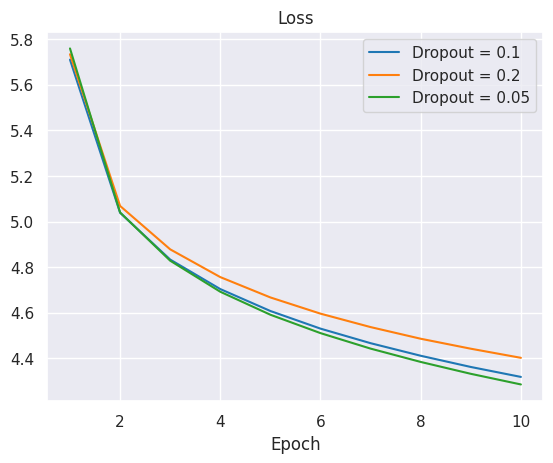

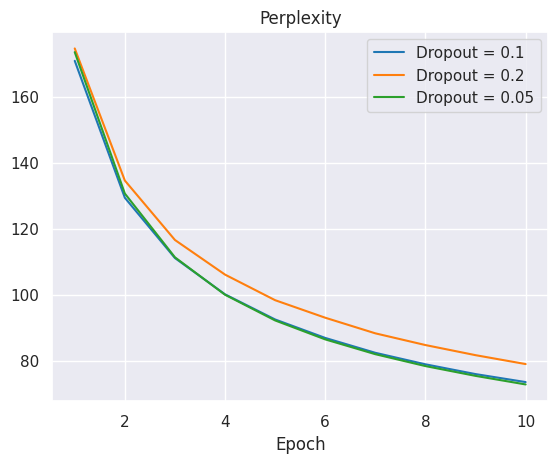

In [ ]:
plt.plot(np.arange(1, len(losses)+1),   losses,   label='Dropout = 0.1', color='tab:blue')
plt.plot(np.arange(1, len(losses_do2)+1), losses_do2, label='Dropout = 0.2', color='tab:orange')
plt.plot(np.arange(1, len(losses_do05)+1), losses_do05, label='Dropout = 0.05', color='tab:green')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

plt.plot(np.arange(1, len(perplexities)+1), perplexities,   label='Dropout = 0.1', color='tab:blue')
plt.plot(np.arange(1, len(perplexities_do2)+1), perplexities_do2, label='Dropout = 0.2', color='tab:orange')
plt.plot(np.arange(1, len(perplexities_do05)+1), perplexities_do05, label='Dropout = 0.05', color='tab:green')
plt.title('Perplexity')
plt.xlabel('Epoch')
plt.legend()
plt.show()

Повышение dropout выше 0.1 начинает мешать - модель теряет способность хорошо подстраиваться под данные. Уменьшение же наоборот - обеспечило наименьшие значения как лосса, так и перплексии.

# Отчет (2 балла)

Итак, взяв за основу модель с одним LSTM слоем, размером скрытого состояния равным 128 и dropout = 0.1, мы узнали, что произойдет, если внести изменения в num_layers, hidden_dim, вид rnn-слоя и регуляризацию.

Посмотрим на все графики разом:

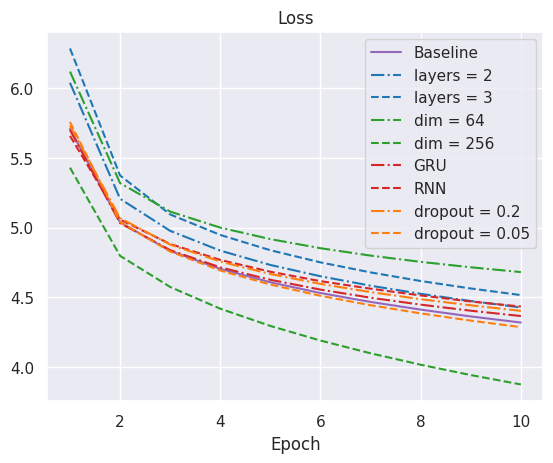

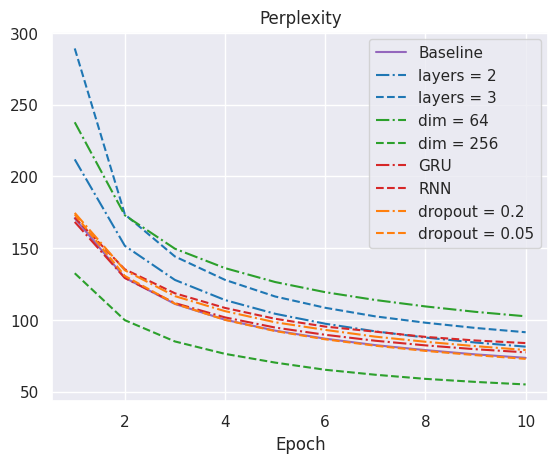

In [ ]:
plt.plot(np.arange(1, len(losses)+1),   losses,   label='Baseline', color='tab:purple', linestyle = '-')
plt.plot(np.arange(1, len(losses_2)+1), losses_2, label='layers = 2', color='tab:blue', linestyle = '-.')
plt.plot(np.arange(1, len(losses_3)+1), losses_3, label='layers = 3', color='tab:blue', linestyle = '--')
plt.plot(np.arange(1, len(losses_64)+1), losses_64, label='dim = 64', color='tab:green', linestyle = '-.')
plt.plot(np.arange(1, len(losses_256)+1), losses_256, label='dim = 256', color='tab:green', linestyle = '--')
plt.plot(np.arange(1, len(losses_gru)+1), losses_gru, label='GRU', color='tab:red', linestyle = '-.')
plt.plot(np.arange(1, len(losses_rnn)+1), losses_rnn, label='RNN', color='tab:red', linestyle = '--')
plt.plot(np.arange(1, len(losses_do2)+1), losses_do2, label='dropout = 0.2', color='tab:orange', linestyle = '-.')
plt.plot(np.arange(1, len(losses_do05)+1), losses_do05, label='dropout = 0.05', color='tab:orange', linestyle = '--')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

plt.plot(np.arange(1, len(perplexities)+1), perplexities,   label='Baseline', color='tab:purple', linestyle = '-')
plt.plot(np.arange(1, len(perplexities_2)+1), perplexities_2, label='layers = 2', color='tab:blue', linestyle = '-.')
plt.plot(np.arange(1, len(perplexities_3)+1), perplexities_3, label='layers = 3', color='tab:blue', linestyle = '--')
plt.plot(np.arange(1, len(perplexities_64)+1), perplexities_64, label='dim = 64', color='tab:green', linestyle = '-.')
plt.plot(np.arange(1, len(perplexities_256)+1), perplexities_256, label='dim = 256', color='tab:green', linestyle = '--')
plt.plot(np.arange(1, len(perplexities_gru)+1), perplexities_gru, label='GRU', color='tab:red', linestyle = '-.')
plt.plot(np.arange(1, len(perplexities_rnn)+1), perplexities_rnn, label='RNN', color='tab:red', linestyle = '--')
plt.plot(np.arange(1, len(perplexities_do2)+1), perplexities_do2, label='dropout = 0.2', color='tab:orange', linestyle = '-.')
plt.plot(np.arange(1, len(perplexities_do05)+1), perplexities_do05, label='dropout = 0.05', color='tab:orange', linestyle = '--')
plt.title('Perplexity')
plt.xlabel('Epoch')
plt.legend()
plt.show()


И на сводную таблицу:

In [ ]:
import pandas as pd
import numpy as np

def summarize(name, losses, ppl):
    rows = []
    l = np.array(losses)
    a = np.array(ppl)
    min_loss = float(l.min())
    min_loss_epoch = int(l.argmin())
    best_ppl = float(a.min())
    best_ppl_epoch = int(a.argmin())
    rows.append([name, min_loss,
                  best_ppl, best_ppl_epoch])
    return rows

rows = []
rows += summarize("LSTM, dim = 128, layers = 1, dropout = 0.1", losses, perplexities)
rows += summarize("GRU, dim = 128, layers = 1, dropout = 0.1", losses_gru, perplexities_gru)
rows += summarize("RNN, dim = 128, layers = 1, dropout = 0.1", losses_rnn, perplexities_rnn)
rows += summarize("LSTM, dim = 128, layers = 2, dropout = 0.1", losses_2, perplexities_2)
rows += summarize("LSTM, dim = 128, layers = 3, dropout = 0.1", losses_3, perplexities_3)
rows += summarize("LSTM, dim = 64, layers = 1, dropout = 0.1", losses_64, perplexities_64)
rows += summarize("LSTM, dim = 256, layers = 1, dropout = 0.1", losses_256, perplexities_256)
rows += summarize("LSTM, dim = 128, layers = 1, dropout = 0.2", losses_do2, perplexities_do2)
rows += summarize("LSTM, dim = 128, layers = 1, dropout = 0.05", losses_do05, perplexities_do05)

cols = ["model", "min_loss", "best_ppl", "best_ppl_epoch"]
df = pd.DataFrame(rows, columns=cols)

df_sorted = df.sort_values(by="best_ppl").reset_index(drop=True)
df_sorted


,model,min_loss,best_ppl,best_ppl_epoch
0,"LSTM, dim = 256, layers = 1, dropout = 0.1",3.873629,54.971305,9
1,"LSTM, dim = 128, layers = 1, dropout = 0.05",4.285315,72.796945,9
2,"LSTM, dim = 128, layers = 1, dropout = 0.1",4.318346,73.516094,9
3,"GRU, dim = 128, layers = 1, dropout = 0.1",4.364991,77.345278,9
4,"LSTM, dim = 128, layers = 1, dropout = 0.2",4.402114,78.969025,9
5,"LSTM, dim = 128, layers = 2, dropout = 0.1",4.426679,81.325861,9
6,"RNN, dim = 128, layers = 1, dropout = 0.1",4.433187,83.813526,9
7,"LSTM, dim = 128, layers = 3, dropout = 0.1",4.515498,91.366605,9
8,"LSTM, dim = 64, layers = 1, dropout = 0.1",4.680560,102.487731,9


Все лоссы и перплексии стабильно убывают, а значит обучение идет.

Очевидным преимуществом обладает архитектура с одним LSTM слоем и размером скрытого состояния равным 256. Также улучшение наступило при уменьшении dropout.

Заметим, что архитектура, взятая нами за основу эксперимента, оказалась одной из самых удачных.

Хуже всех сработали трехслойный lstm и lstm с размерностью 64. С последним - ожидаемо, маленький размер скрытого состояния - меньше информации. А множество слоев чревато затуханием градиентов.

Что можно попробовать дальше (если хочется уменьшить PPL)

*   Weight decay 1e-4 для многослойных вариантов;
*   Learning-rate schedule, gradient clipping (например, 1.0);
*   Улучшить токенизацию (BPE/WordPiece) или увеличить vocab до разумной границы;
*   BiRNN и прочие более сложные архитектуры.

А в этой таблице можно посмотреть на результаты моделей на тестовой выборке:

In [5]:
values = [
    test_ppl,
    test_ppl_256,
    test_ppl_64,
    test_ppl_gru,
    test_ppl_rnn,
    test_ppl_2,
    test_ppl_3,
    test_ppl_do2,
    test_ppl_do05
]

models = [
    "LSTM_128_1_0.1",
    "LSTM_256_1_0.1",
    "LSTM_64_1_0.1",
    "GRU_128_1_0.1",
    "RNN_128_1_0.1",
    "LSTM_128_2_0.1",
    "LSTM_128_3_0.1",
    "LSTM_128_1_0.2",
    "LSTM_128_1_0.05",
]


df = pd.DataFrame({"Model": models, "Test perplexity": values})
pd.options.display.float_format = "{:.4f}".format
print(df)

             Model  Test perplexity
0   LSTM_128_1_0.1          73.6693
1   LSTM_256_1_0.1          55.0966
2    LSTM_64_1_0.1         102.5516
3    GRU_128_1_0.1          77.4928
4    RNN_128_1_0.1          83.9586
5   LSTM_128_2_0.1          81.5104
6   LSTM_128_3_0.1          91.5054
7   LSTM_128_1_0.2          79.0517
8  LSTM_128_1_0.05          73.0031


А теперь увеличим количество эпох до 25 и сравним нашу улучшенную модель

**LSTM, hidden_dim=256, num_layers=1, dropout=0.05**

с базовой:

**LSTM, hidden_dim=128, num_layers=1, dropout=0.1**

In [ ]:
model_start = LanguageModel(hidden_dim=128, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model_start.parameters(), lr=1e-3)

In [ ]:
losses_start, perplexities_start = train_model(model_start, train_dataloader, eval_dataloader, criterion, optimizer, num_epoch=25)

Training epoch 0::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/1243 [00:00<?, ?it/s]

...

Training epoch 20::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 21::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 22::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 23::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 24::   0%|          | 0/1243 [00:00<?, ?it/s]

Измерим перплексию на тестовой выборке:

In [ ]:
test_ppl_start = evaluate(model_start, criterion, test_dataloader)
test_ppl_start

57.90135681859314

In [ ]:
model_final = LSTM_Do05_Model(hidden_dim=256, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model_final.parameters(), lr=1e-3)

In [ ]:
losses_final, perplexities_final = train_model(model_final, train_dataloader, eval_dataloader, criterion, optimizer, num_epoch=25)

Training epoch 0::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/1243 [00:00<?, ?it/s]

...

Training epoch 20::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 21::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 22::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 23::   0%|          | 0/1243 [00:00<?, ?it/s]

Training epoch 24::   0%|          | 0/1243 [00:00<?, ?it/s]

Измерим перплексию на тестовой выборке:

In [ ]:
test_ppl_final = evaluate(model_final, criterion, test_dataloader)
test_ppl_final

43.29928419734213

Посмотрим на графики:

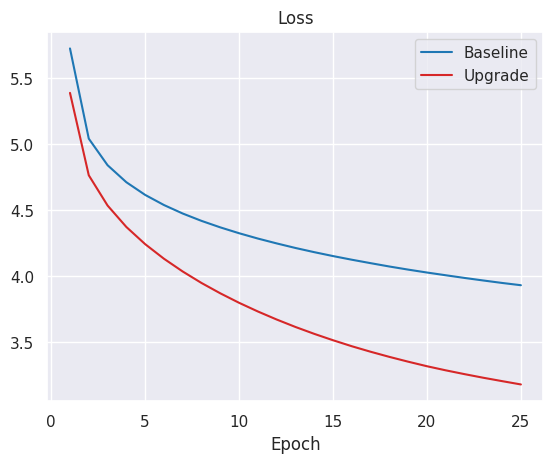

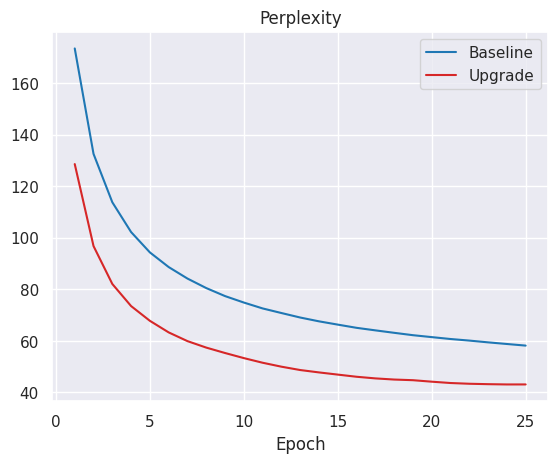

In [ ]:
plt.plot(np.arange(1, len(losses_start)+1),   losses_start,   label='Baseline', color='tab:blue', linestyle = '-')
plt.plot(np.arange(1, len(losses_final)+1), losses_final, label='Upgrade', color='tab:red', linestyle = '-')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

plt.plot(np.arange(1, len(perplexities_start)+1), perplexities_start,   label='Baseline', color='tab:blue', linestyle = '-')
plt.plot(np.arange(1, len(perplexities_final)+1), perplexities_final, label='Upgrade', color='tab:red', linestyle = '-')
plt.title('Perplexity')
plt.xlabel('Epoch')
plt.legend()
plt.show()


Превосходство очевидно :) И выигрыш в перплексии составил:

In [ ]:
perplexities_start[-1]-perplexities_final[-1]

15.054009492793142

А теперь посмотрим на результат генерации:

In [ ]:
import re

def detok(s: str) -> str:
    s = re.sub(r"\s+([.,!?;:])", r"\1", s)
    s = re.sub(r"\s+(n't|'re|'ve|'ll|'d|'m|'s)\b", r"\1", s)
    s = re.sub(r"\(\s+", "(", s); s = re.sub(r"\s+\)", ")", s)
    s = re.sub(r'\s+"', '"', s); s = re.sub(r'"\s+', '"', s)
    return re.sub(r"\s+", " ", s).strip()


In [ ]:
def generate_sequence(model, starting_seq: str, max_seq_len: int = 128) -> str:
    device = next(model.parameters()).device
    model.eval()

    input_ids = [word2ind['<bos>']] + [
        word2ind.get(w, word2ind['<unk>']) for w in starting_seq.split()
    ]
    input_ids = torch.tensor([input_ids], dtype=torch.long, device=device)  # [1, T]

    with torch.no_grad():
        for _ in range(max_seq_len):
            logits = model(input_ids)              # [1, T, V]
            next_logits = logits[:, -1, :]         # [1, V]
            next_id = next_logits.argmax(dim=-1)   # [1]
            input_ids = torch.cat([input_ids, next_id.unsqueeze(1)], dim=1)
            if next_id.item() == word2ind['<eos>']:
                break

    ids = input_ids[0].tolist()
    eos_pos = ids.index(word2ind['<eos>']) if word2ind['<eos>'] in ids else len(ids)
    ids = ids[1:eos_pos]
    text = ' '.join(ind2word[i] for i in ids)
    return detok(text)


Было:

In [ ]:
generate_sequence(model_start, starting_seq='it', max_seq_len = 1000)

'it was a great movie.'

Стало:

In [ ]:
generate_sequence(model_final, starting_seq='it', max_seq_len = 1000)

"it's not a bad movie, but it's not even close to the book."

Неплохо, как по мне :)

Благодарю за прочтение 🙏💙